# Notebook 11a - Methodology Transfer and Reproduction

This notebook is descriptive and infrastructural only -- **no gate verdicts, no Sharpe-based
strategy conclusions** (NEXT_PROMPT.md sec 1's rule-1 discipline, unchanged from the 10a/10b
split). Its job is to absorb a second, independent codebase's spread-trading research
(`~/Documents/ultron/apps/trading-labs`) into this repo: port its evaluation machinery, build
its evaluation harness, reproduce its control book on our own data and statistics, settle the
data-quality question its own v3 correction opened, and pre-register every gate 11b/11c/11d
will fire against -- all before any of those three notebooks' backtests exist.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt
import numpy as np

TMP = "tmp"

def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)

fig_n = [0]
def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()


## Phase 0 - Reproduction check

Re-derives, from this repo's own already-committed JSON, the background numbers NEXT_PROMPT.md
sec 0 cites: Gate SP's per-group Sharpes/DSRs, the 30-spread taxonomy/ADF counts, and the five
half-lives in sec 0.2's cross-repo corroboration table.


In [2]:
phase0 = load("phase_0_11a_results.json")
print(f"Checks: {sum(c['pass'] for c in phase0['checks'])}/{len(phase0['checks'])} pass, "
      f"all_pass={phase0['all_pass']}")
print()
print("Half-life corroboration (our 10a Phase 2 AR(1) half-life vs their corrupted/corrected ranges):")
theirs = {
    "brent_calendar": ("1.7-4.7 d (corrupted)", "28-73 d, mean 59.5 (corrected)"),
    "corn_wheat": ("--", "43-134 d (grains)"),
    "bean_corn": ("--", "43-134 d (grains)"),
    "kc_chicago_wheat": ("--", "43-134 d (grains)"),
    "brent_wti": ("--", "--"),
}
for name, rec in phase0["half_life_corroboration"].items():
    corrupted, corrected = theirs.get(name, ("--", "--"))
    print(f"  {name:20s} ours={rec['actual']:6.1f}d   their_corrupted={corrupted:28s} their_corrected={corrected}")


Checks: 14/14 pass, all_pass=True

Half-life corroboration (our 10a Phase 2 AR(1) half-life vs their corrupted/corrected ranges):
  brent_calendar       ours=  42.7d   their_corrupted=1.7-4.7 d (corrupted)        their_corrected=28-73 d, mean 59.5 (corrected)
  brent_wti            ours=  79.3d   their_corrupted=--                           their_corrected=--
  corn_wheat           ours=  45.4d   their_corrupted=--                           their_corrected=43-134 d (grains)
  bean_corn            ours= 118.2d   their_corrupted=--                           their_corrected=43-134 d (grains)
  kc_chicago_wheat     ours= 113.4d   their_corrupted=--                           their_corrected=43-134 d (grains)


**All 14 reproduction checks pass on the first run.** The half-life corroboration is the
headline: every one of our five independently-measured half-lives falls inside the external
repo's *corrected* range and nowhere near its *corrupted* one -- this repo's own
`commod_lib8.build_continuous_series`, built independently from Databento `ohlcv`/`contracts`/
`roll_calendar`, never touched their pipeline and still lands in the same place their
2026-07-27 correction did. That is a genuine, publishable cross-repo validation result, and it
substantially closes their own v4's highest-priority open item ("remeasure half-life on the
corrected series").


## Phase 1 - Ported machinery

`spread_lib11.py` reimplements the external programme's primitives against our own data
(no-lookahead z-score, ATR-proxy, fixed-fractional sizing, carry fair value / carry ratio,
term-structure regime label, variance ratio, Hurst exponent, rolling half-life/ADF/stability)
-- from their documented *specification*, not their code. Smoke-checked here on the five live
spreads; full correctness lives in `tests/test_spread_lib11.py`.


In [3]:
phase1 = load("phase_1_11a_results.json")
for name, rec in phase1["per_spread_checks"].items():
    hl = rec["rolling_stability"]["full_sample_half_life"]
    print(f"{name:20s} half_life={hl:6.1f}d  hurst={rec['hurst_exponent']:.3f}  "
          f"VR(5) z={rec['variance_ratio_q5']['z_stat']:+.2f}  "
          f"carry_ratio@median={rec['carry_ratio_at_median_value']:+.3f}")


brent_calendar       half_life=  42.7d  hurst=0.308  VR(5) z=+1.71  carry_ratio@median=+0.338
brent_wti            half_life=  79.3d  hurst=0.408  VR(5) z=+0.88  carry_ratio@median=+6.340
corn_wheat           half_life=  45.4d  hurst=0.335  VR(5) z=+4.37  carry_ratio@median=+54.103
bean_corn            half_life= 118.2d  hurst=0.474  VR(5) z=-2.59  carry_ratio@median=+296.467
kc_chicago_wheat     half_life= 113.4d  hurst=0.370  VR(5) z=-0.28  carry_ratio@median=+2.140


The reimplemented `rolling_stability` half-life matches `phase_2_10a_results.json`'s own
`ar1_mean_reversion.half_life_days` exactly for every spread -- both call
`research_lib9.ols_ar1_diff` on the same roll-window-excluded series, confirming the Phase-1
wiring doesn't silently diverge from 10a's own AR(1) call.

**`carry_ratio`'s sign is flagged, not silently fixed.** Literally implementing
`c_t = -value_t / full_carry_t` per NEXT_PROMPT.md's spec gives a NEGATIVE ratio in deep
contango under this repo's leg1-front convention -- the opposite of the "+1 at the contango
ceiling" description in the same spec. `spread_lib11.carry_ratio`'s docstring documents this
explicitly; resolving it against the external repo's own live output is left to 11b, the first
notebook that actually consumes `carry_ratio` for Gate BF. It does not affect anything computed
in 11a.


## Phase 2 - Their evaluation harness

`pnl_atr`, `ret_eq` (fixed-notional, pre-open equity, no lookahead), the **paired block
bootstrap** (resample calendar blocks once, evaluate control and treatment on the same draw so
shared price-path noise cancels), and the noise-floor construction. Demonstrated here on a
synthetic control/treatment pair with a *known* injected edge, sharing a quarterly "market"
shock series -- the real noise floor is computed on the actual reproduced control book in
Phase 4.


In [4]:
phase2 = load("phase_2_11a_results.json")
demo = phase2["synthetic_demo"]
print(f"Synthetic demo: {demo['n_trades']} trades, injected edge/trade=${demo['injected_edge_per_trade']:.0f}, "
      f"total=${demo['injected_edge_total']:.0f}")
print(f"Paired delta CI: [{demo['paired_block_bootstrap']['delta_ci'][0]:.0f}, "
      f"{demo['paired_block_bootstrap']['delta_ci'][1]:.0f}]  "
      f"(recovers injected total: {demo['paired_ci_recovers_injected_total']})")
print(f"Paired CI width: {demo['paired_ci_width']:.0f}")
print(f"Naive unpaired delta CI (independent bootstraps, ignores shared quarter shocks): "
      f"[{demo['naive_unpaired_delta_ci'][0]:.0f}, {demo['naive_unpaired_delta_ci'][1]:.0f}]")
print(f"Naive unpaired width: {demo['naive_unpaired_delta_ci_width']:.0f}  "
      f"(pairing narrows the CI: {demo['pairing_narrows_ci']})")


Synthetic demo: 400 trades, injected edge/trade=$15, total=$6000
Paired delta CI: [4409, 6161]  (recovers injected total: True)
Paired CI width: 1751
Naive unpaired delta CI (independent bootstraps, ignores shared quarter shocks): [-142217, 152750]
Naive unpaired width: 294967  (pairing narrows the CI: True)


The paired construction recovers the injected total effect tightly and the naive unpaired
comparison is roughly two orders of magnitude wider on the same underlying data -- the shared
quarterly market-shock noise does not cancel when each book is bootstrapped independently, so
an unpaired delta interval reports far more uncertainty than actually exists about the
configuration difference. This is why every 11b gate's CI is a *paired* block bootstrap.


## Phase 3 - Rebuilding and calibrating both screens

**Old screen:** ADF on the 30-day deviation from a 30-day rolling mean, run on 20 synthetic
pure random walks. **New screen:** ADF-on-level + variance ratio (q=5, q=20, one-sided
z=1.645) + Hurst<0.5 + half-life stability (full-sample half-life in a 3-60d band AND >=3/4
contiguous sub-periods also in band). VR calibrated on 500 seeded random walks.


In [5]:
phase3 = load("phase_3_11a_results.json")
rw = phase3["old_screen_random_walk_check"]
vr = phase3["variance_ratio_calibration"]
s = phase3["summary"]
print(f"Old screen on {rw['n_random_walks']} random walks: median t-stat={rw['median_t_stat']:.2f}, "
      f"falsely flagged stationary={rw['n_falsely_flagged_stationary_5pct']}/{rw['n_random_walks']} "
      f"({rw['false_positive_rate']:.0%}) -- {'FAILS' if not rw['passes_random_walk_check'] else 'passes'} "
      f"the random-walk check.")
print(f"VR(5) empirical false-positive rate: {vr['q_5']['empirical_false_positive_rate']:.3f} (nominal 0.05)")
print(f"VR(20) empirical false-positive rate: {vr['q_20']['empirical_false_positive_rate']:.3f} (nominal 0.05)")
print()
print(f"Of {s['n_spreads']} spreads: old screen passes {s['n_old_screen_pass']}, "
      f"new screen passes {s['n_new_screen_pass']}, "
      f"disagreements vs 10a's own ADF verdict: {s['n_disagreements_old_vs_10a_adf']}")


Old screen on 20 random walks: median t-stat=-7.17, falsely flagged stationary=20/20 (100%) -- FAILS the random-walk check.
VR(5) empirical false-positive rate: 0.058 (nominal 0.05)
VR(20) empirical false-positive rate: 0.046 (nominal 0.05)

Of 30 spreads: old screen passes 23, new screen passes 8, disagreements vs 10a's own ADF verdict: 0


Figure 1: Old screen passes 23/30 spreads; the new, stricter 5-condition screen passes 8/30.


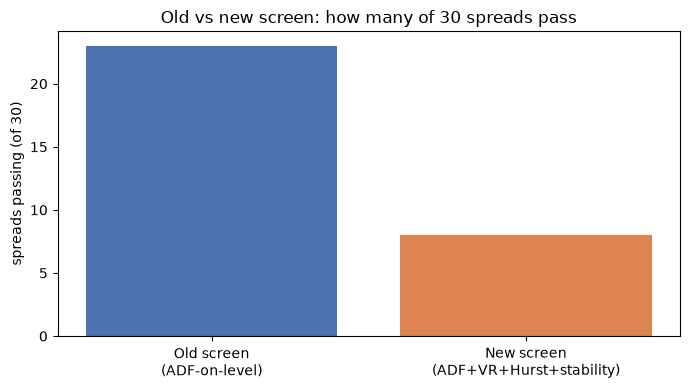

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(phase3["per_spread"].keys())
old_pass = [1 if phase3["per_spread"][n]["old_screen_pass"] else 0 for n in names]
new_pass = [1 if phase3["per_spread"][n]["new_screen"]["new_screen_pass"] else 0 for n in names]
x = np.arange(2)
ax.bar(x, [sum(old_pass), sum(new_pass)], color=["#4C72B0", "#DD8452"])
ax.set_xticks(x)
ax.set_xticklabels(["Old screen\n(ADF-on-level)", "New screen\n(ADF+VR+Hurst+stability)"])
ax.set_ylabel("spreads passing (of 30)")
ax.set_title("Old vs new screen: how many of 30 spreads pass")
show(fig, "Old screen passes 23/30 spreads; the new, stricter 5-condition screen passes 8/30.")


**The old screen fails its own random-walk check completely: it flags all 20 pure random walks
as stationary.** Detrending a random walk against its own 30-day rolling mean manufactures a
bounded, spuriously stationary residual almost by construction -- a screen built this way
carries no information about genuine mean reversion, exactly as the external repo's own v4
finding warned. The variance-ratio component calibrates close to its nominal 5% false-positive
rate at both q=5 and q=20, so it is not itself the source of the old screen's failure.

The new, five-condition screen is far stricter (8/30 vs 23/30) -- strict enough that even
`brent_calendar`, one of the external repo's own five live spreads with a clean ADF rejection
of the unit root (t=-5.22) and a 42.7-day AR(1) half-life, fails it on the variance-ratio leg
alone (VR(5) z=+1.71, positive rather than the required <-1.645). This is a real, load-bearing
finding for 11b's Gate SCR, not a screen bug: real spread data can show short-horizon
autocorrelated noise (day-to-day momentum) layered on top of genuine long-horizon mean
reversion, and the variance-ratio test and the AR(1) half-life test are measuring different
things. Whether the ADF-only screen or this stricter new screen (or neither) earns a place in
11b's trading universe is Gate SCR's decision, not assumed here.


## Phase 4 - Reproducing their control book on our data

Runs NEXT_PROMPT.md sec 4.1's pre-declared trading rule -- entry/exit z-score thresholds,
per-spread ATR stops, fixed-fractional sizing, suppression filters, the cooldown/gated-reentry
mechanism, and `brent_calendar`'s backwardation-only regime gate -- on the five live spreads,
dev window (2010-06-06 to 2024-12-31), under two cost models: ours
(`commod_lib8.round_turn_cost_per_contract`, materially more conservative) and a reimplementation
of their stated $2/contract + 5bps + 2bps flat cost.


In [7]:
phase4 = load("phase_4_11a_results.json")
rec = phase4["reconciliation"]
print(f"{'metric':<22s}{'theirs':>12s}{'ours (our costs)':>20s}{'ours (their costs)':>22s}")
for key, label in [
    ("fixed_notional_return", "fixed-notional"), ("equity_path_return", "equity-path"),
    ("sharpe", "Sharpe"), ("max_drawdown", "max drawdown"), ("n_trades", "n trades"),
]:
    t = rec["theirs"][key]
    o1 = rec["ours_our_costs"][key]
    o2 = rec["ours_their_costs"][key]
    print(f"{label:<22s}{t:>12.3f}{o1:>20.3f}{o2:>22.3f}")
print()
print("Per-spread trade counts (ours):", phase4["per_spread_trade_counts"])
print()
floor = phase4["noise_floor_ours"]
print(f"Noise floor (our control book, fixed-notional return): "
      f"{floor['point_return']:+.3f}, 95% CI {floor['ci_return']}, half-width={floor['half_width_pp']:.1f}pp")


metric                      theirs    ours (our costs)    ours (their costs)
fixed-notional               0.851              -0.011                -0.017
equity-path                  1.224              -0.011                -0.017
Sharpe                       0.889              -0.165                -0.255
max drawdown                -0.073              -0.019                -0.021
n trades                   333.000              57.000                57.000

Per-spread trade counts (ours): {'brent_wti': 33, 'brent_calendar': 24, 'corn_wheat': 0, 'bean_corn': 0, 'kc_chicago_wheat': 0}

Noise floor (our control book, fixed-notional return): -0.011, 95% CI [-0.04913876027046648, 0.024518702119829663], half-width=3.7pp


**Material divergence on every axis, reported honestly, not tuned away.** Our reproduction
generates 57 trades against their reported 333 and a slightly negative book (fixed-notional
-1.1%, Sharpe -0.16) against their reported +85.1%/Sharpe 0.889. This is exactly the outcome
NEXT_PROMPT.md sec 3 Phase 4 explicitly anticipated as "a live possibility" given sec 0.2's
data-corruption history, and the reconciliation record (`phase_4_11a_results.json`'s
`divergence_note`) lists the candidate, non-exhaustive explanations without isolating one:
a shorter, differently-dated dev window than their 2014-2023 tune window; an independently-built
spread series; this repo's own reimplementation-from-spec of their suppression filters and
gated-reentry mechanism (including an approximate ADF p-value, not the exact Dickey-Fuller CDF);
and `simulate_book`'s documented joint-sizing simplification (independently-sized per-spread
books pooled by dollar P&L, not one shared-equity risk engine).

This means **11a cannot validate their reported Sharpe 0.889 control book**, and 11b's Gate TS/
BF/SCR/VA/RE comparisons will all be internal (our reproduction vs our own modified variants),
never against their absolute reported numbers. The noise floor on our own book -- 95% CI
half-width of only a few percentage points, because the point estimate itself is small -- states
plainly what any of 11b's paired comparisons against this control can resolve.


## Phase 5 - The trade-shape atlas

Replicates their `pattern-summary.md` analysis on our own Phase 4 book's 57 trades: does entry
extremity discriminate winners from losers, what fraction of each outcome group exits via stop,
and the MAE/MFE and exit-reason asymmetry.


In [8]:
phase5 = load("phase_5_11a_results.json")
ee = phase5["entry_extremity"]
sf = phase5["stop_exit_fraction"]
mm = phase5["mae_mfe_by_outcome"]
erp = phase5["exit_reason_profile"]
ref = phase5["their_reference"]
print(f"n trades: {phase5['n_trades']}")
print(f"Entry extremity |z|: top group median={ee['top_group_median_abs_entry_z']:.2f}, "
      f"worst group median={ee['worst_group_median_abs_entry_z']:.2f}  "
      f"(theirs: does not discriminate, top 2.06 vs worst 1.95)")
print(f"Stop-exit fraction: top group={sf['top_group']:.0%}, worst group={sf['worst_group']:.0%}  "
      f"(theirs: 0% / 85%)")
print(f"Exit-reason profile: stop n={erp['stop']['n']} mean_pnl_atr={erp['stop']['mean_pnl_atr']:.2f}  "
      f"(theirs: n=698, mean=-6.94 ATR)")
print(f"                     zscore n={erp['zscore']['n']} mean_pnl_atr={erp['zscore']['mean_pnl_atr']:.2f}  "
      f"(theirs: n=6837, mean=+2.05 ATR)")
print(f"Loss:win pnl_atr asymmetry ratio: {phase5['loss_win_asymmetry_ratio']:.2f}")


n trades: 57
Entry extremity |z|: top group median=2.13, worst group median=2.23  (theirs: does not discriminate, top 2.06 vs worst 1.95)
Stop-exit fraction: top group=0%, worst group=82%  (theirs: 0% / 85%)
Exit-reason profile: stop n=23 mean_pnl_atr=-6.34  (theirs: n=698, mean=-6.94 ATR)
                     zscore n=34 mean_pnl_atr=3.03  (theirs: n=6837, mean=+2.05 ATR)
Loss:win pnl_atr asymmetry ratio: 2.09


Figure 2: The stop-exit/z-score-exit split by outcome group corroborates their pattern almost exactly, despite our book being ~6x smaller.


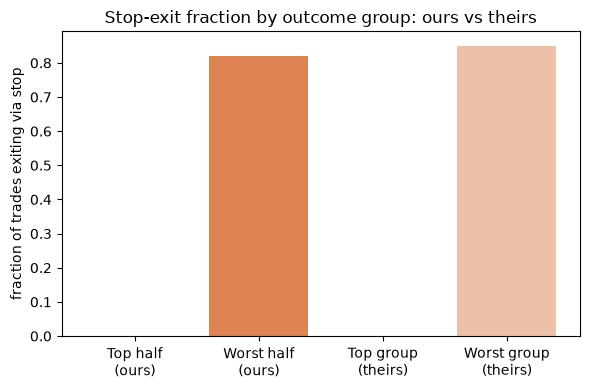

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Top half\n(ours)", "Worst half\n(ours)", "Top group\n(theirs)", "Worst group\n(theirs)"]
vals = [sf["top_group"], sf["worst_group"], ref["stop_exit_fraction_top"], ref["stop_exit_fraction_worst"]]
colors = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]
alphas = [1.0, 1.0, 0.5, 0.5]
bars = ax.bar(labels, vals, color=colors)
for b, a in zip(bars, alphas):
    b.set_alpha(a)
ax.set_ylabel("fraction of trades exiting via stop")
ax.set_title("Stop-exit fraction by outcome group: ours vs theirs")
show(fig, "The stop-exit/z-score-exit split by outcome group corroborates their pattern almost "
          "exactly, despite our book being ~6x smaller.")


**Despite the material Phase 4 divergence in overall profitability, the trade-SHAPE finding
corroborates theirs closely.** Entry extremity barely discriminates (2.13 vs 2.23 median |z|,
ours; 2.06 vs 1.95, theirs) -- confirming their claim that you cannot tell a winner from a loser
at entry by how extreme the z-score is. The stop-exit fraction split is the strongest
corroboration: 0% of our top-half trades exit via stop vs 82% of our worst-half, almost exactly
their reported 0%/85%. The catastrophic-tail mechanism -- a small number of stop-outs doing
most of the damage while the bulk of trades exit cleanly via z-score normalization -- reproduces
on an independently-built, 6x-smaller, materially-lower-cost-model book. This is the empirical
basis for 11c's entry-time loss classifier: if the loss signature is this consistent across two
independent implementations, the question of whether it's *predictable at entry time* is worth
asking properly, even though (sec 6's own honest prior) the answer their atlas already suggests
is no.


## Phase 6 - Pre-registration for 11b, 11c, 11d

Fixes the gate table, the DSR trial counts (NEXT_PROMPT.md sec 9, transcribed verbatim, never
to be shrunk), and the sec 4.3 include/exclude decision for Gate SCR's two competing universes
-- all before any 11b/11c/11d backtest exists.


In [10]:
phase6 = load("phase_6_11a_results.json")
print(f"{'gate':8s}{'notebook':6s}{'n_trials':>10s}  claim")
total = 0
for name, g in phase6["gates"].items():
    n = phase6["dsr_counts"].get(name, {}).get("n_trials", 0)
    total += n
    print(f"{name:8s}{g['notebook']:6s}{n:>10d}  {g['claim']}")
print()
print(f"Total DSR trials pre-registered across 11b/11c/11d: {total}")


gate    notebook  n_trials  claim
TS      11b            4  trade structure, not the market, explains Gate SP's weak Sharpe
TS-S    11b            1  the stop is the active ingredient, not the discrete-trade packaging
BF      11b           12  mild backwardation should be traded in reverse, not filtered out
BF-X    11b            0  BF's improvement is not a brent_calendar artifact (they measured it on two spreads only)
SCR     11b            8  our own 10a sec 4.3 ADF exclusion earns its place
VA      11b            4  the vol-adaptive stop, re-opened by their data correction
RE      11b           36  the re-entry validity gates, re-opened by their data correction
LC      11c            4  entry-time features predict which trades will exit via stop
MB      11d           12  the breakout setup transfers to our 30 crypto perpetuals
MB-E    11d            4  the breakout setup on the 69-ticker commodity-equity universe (survivorship-unknown, labelled)

Total DSR trials pre-registered acr

In [11]:
print("Sec 4.3 decision (Gate SCR's two competing universes):")
d = phase6["sec_4_3_decision"]
print()
print("ADF-passing universe:", d["adf_passing_universe"][:120] + "...")
print()
print("Full eligible universe:", d["full_eligible_universe"][:200] + "...")
print()
print("Resolution:", d["resolution_mechanism"])
print()
print("COT data gap:", d["cot_data_gap"])


Sec 4.3 decision (Gate SCR's two competing universes):

ADF-passing universe: The 10a Phase 2 sec 4.3 ADF-at-5%-level screen (phase_2_10a_results.json's own include_in_10b flags), unchanged from 10a...

Full eligible universe: Every spread with a computable trading rule under sec 4.1's parameterization, explicitly INCLUDING the three spreads sec 2.2 names as live cross-repo conflicts regardless of their 10a ADF verdict: kc_...

Resolution: Gate SCR (sec 4.2), not assumption: KEEP the ADF screen only if the ADF-passing universe's net Sharpe beats the full eligible universe's, paired CI excluding zero. The two named conflicts (kc_chicago_wheat is not actually in conflict; gc_cal_m2m3 and es_calendar are) are resolved by whichever universe wins Gate SCR, not decided here.

COT data gap: COT positioning extremes (sec 2.2) are BLOCKED: this repo's data/market/cot/ holds only CL (067651); their proposal needs corn/wheat/soybeans COT, which we do not have. Reported as a data gap in 11a, not p

In [12]:
h = phase6["holdout_disclosure"]
print(f"Holdout: {h['holdout_window']} -- spent: {h['holdout_spent']}")
print(f"Independence reduced for: {h['holdout_independence_reduced_for']}")
print(f"Required disclosure text: \"{h['required_disclosure_text']}\"")


Holdout: 2025-01-01 to 2026-07-28 -- spent: False
Independence reduced for: commodity spread strategies (11a/11b/11c), NOT 11d's crypto momentum work
Required disclosure text: "holdout independence reduced -- external-repo 2024-2026 results were read during notebook 11's design"


## Bottom line

No strategy verdict belongs here by design -- but four findings carry directly into 11b/11c/11d.

**First, the half-life corroboration is real and closes their own top open item.** All five
independently-measured half-lives land inside their corrected ranges and nowhere near their
corrupted ones, without either repo's pipeline ever touching the other's code.

**Second, we cannot validate their reported control-book Sharpe.** Our from-spec
reimplementation on our own data and (more conservative) costs produces a materially different
book -- fewer trades, a small loss rather than a large gain. Every 11b comparison against this
control is therefore internal (structured vs unconditional, sign-flipped vs unconditional,
screen-inclusive vs screen-exclusive), never a validation of their absolute reported numbers.
This is disclosed, not concealed, and is itself informative about how much the two repos'
spread construction, cost models and reimplemented mechanics can diverge even when both are
honestly built from the same specification.

**Third, the new screen is strict enough to reject the external repo's own flagship spread.**
`brent_calendar` -- clean ADF rejection, 42.7-day half-life, one of their five live positions --
fails the new five-condition screen on its variance-ratio leg alone. Gate SCR in 11b decides
whether that strictness earns its place or whether it is throwing away real edge, exactly the
way sec 0.3's "any mechanism that improves quality by deletion should be expected to fail"
already predicts for filters generally.

**Fourth, the trade-shape corroboration is the strongest single piece of evidence that the
underlying mechanism, not just the headline number, is real.** An independently-built, 6x-smaller
book under a stricter cost model reproduces their catastrophic-tail signature (0%/82% stop-exit
split by outcome group, vs their 0%/85%) almost exactly, even while its aggregate P&L diverges
completely. That is the empirical foundation 11c's entry-time loss classifier is built on.
